In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("../data/processed/customer_features.csv")

df.head()

,customer_id,total_spent,total_orders,avg_rating
0,CUS1000,13872.12,2,3.250000
1,CUS1001,4835.13,1,3.500000
2,CUS1002,15161.61,2,3.302347
3,CUS1003,11213.44,1,1.800000
4,CUS1005,1695.06,1,1.900000


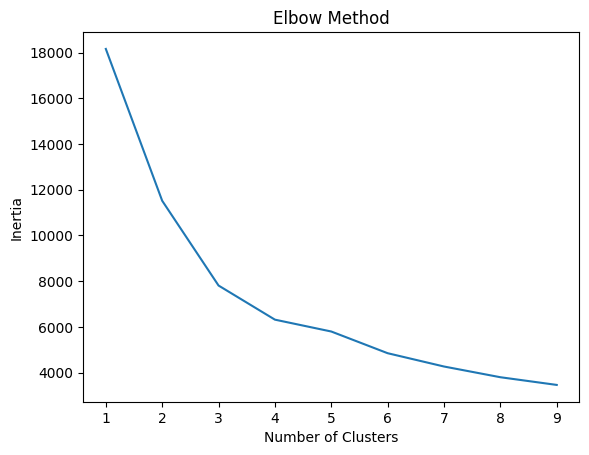

In [3]:
#Select Features for Clustering
X = df[["total_spent","total_orders","avg_rating"]]

#feature scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

#StandardScaler converts data to mean = 0 and standard deviation = 1

#Find Optimal Number of Clusters We use the Elbow Method.
inertia = []

for k in range(1,10):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

#ploting
plt.plot(range(1,10), inertia)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [4]:
#train final k mean model
kmeans = KMeans(n_clusters=3, random_state=42)

df["cluster"] = kmeans.fit_predict(X_scaled)

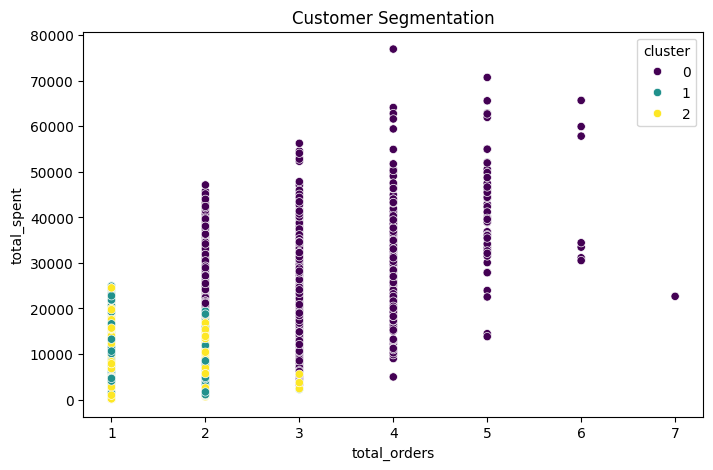

In [10]:
#visualize clusters
#Plot spending vs orders.
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["total_orders"],
    y=df["total_spent"],
    hue=df["cluster"],
    palette="viridis"
)

plt.title("Customer Segmentation")
plt.show()

#This will show different customer groups.





In [ ]:
#analyse clusters
df.groupby("cluster")[["total_spent","total_orders","avg_rating"]].mean()

,total_spent,total_orders,avg_rating
cluster,,,
0,24672.042135,2.770182,3.011940
1,8271.397822,1.257793,3.863787
2,8334.060583,1.287448,2.063156


In [13]:
#save segmented data
df.to_csv("../data/processed/customer_segments.csv", index=False)